In [ ]:
import os
import sys
import json
import math
import random
import warnings
import hashlib
import tarfile
import urllib.request
from copy import deepcopy
from glob import glob
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

try:
    import h5py
except ImportError as exc:
    raise ImportError(
        "h5py is required for the official writer-partitioned FEMNIST files. "
        "Run `%pip install h5py` and rerun the notebook."
    ) from exc

try:
    from opacus import PrivacyEngine
    from opacus.grad_sample import GradSampleModule
    from opacus.accountants import RDPAccountant
    from opacus.accountants.utils import get_noise_multiplier
    OPACUS_AVAILABLE = True
except ImportError:
    PrivacyEngine = None
    GradSampleModule = None
    RDPAccountant = None
    get_noise_multiplier = None
    OPACUS_AVAILABLE = False
    warnings.warn(
        "Opacus is not installed. Run `%pip install opacus` and restart the kernel "
        "before executing the DP sections."
    )
import sys
import subprocess
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import opacus
import gc
import sys
import torch
import opacus
from opacus import PrivacyEngine
from opacus.grad_sample import GradSampleModule
from opacus.accountants import RDPAccountant
from opacus.accountants.utils import get_noise_multiplier

In [ ]:
STUDENT_ID = 98
SEED = STUDENT_ID

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Opacus available:", OPACUS_AVAILABLE)

Device: cuda
Opacus available: True


In [64]:
QUICK_RUN = False
RUN_BASELINE_TRAINING = True
RUN_RECORD_DP = True
RUN_SUBJECT_DP = True
RUN_SENSITIVITY = False
AUTO_DOWNLOAD_FEMNIST = True

NUM_SILOS = 8
MEMBER_FRACTION = 0.50
SILOS_PER_SUBJECT_CHOICES = (1, 2, 3)
SILOS_PER_SUBJECT_WEIGHTS = (0.60, 0.30, 0.10)

NUM_ROUNDS = 10
LOCAL_EPOCHS = 1
BATCH_SIZE = 128 if QUICK_RUN else 512
SUBJECT_DP_BATCH_SIZE = 32 if QUICK_RUN else 128
LEARNING_RATE = 1e-3
CLIENT_FRACTION = 1.0
MAX_SUBJECTS = 100

MAX_ATTACK_SAMPLES_PER_SUBJECT = 100
MAX_RECORD_ATTACK_SAMPLES_PER_CLASS = 2_000 if QUICK_RUN else 20_000
ATTACK_VALIDATION_SUBJECTS_PER_CLASS = 10 if QUICK_RUN else 50

TARGET_EPSILON = 4.0
TARGET_DELTA = 1e-5
MAX_GRAD_NORM = 1.0

print({
    "QUICK_RUN": QUICK_RUN,
    "NUM_ROUNDS": NUM_ROUNDS,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_SILOS": NUM_SILOS,
    "TARGET_EPSILON": TARGET_EPSILON,
    "TARGET_DELTA": TARGET_DELTA,
})

{'QUICK_RUN': False, 'NUM_ROUNDS': 10, 'BATCH_SIZE': 512, 'NUM_SILOS': 8, 'TARGET_EPSILON': 4.0, 'TARGET_DELTA': 1e-05}


***Subsection 1: (Data Preparation)***

In [ ]:
HF_CACHE_DIR = Path("./hf_cache")

def load_femnist_hf(max_subjects=None):
    femnist = load_dataset(
        "flwrlabs/femnist",
        split="train",
        cache_dir=str(HF_CACHE_DIR),
    )
    required_columns = {
        "image",
        "writer_id",
        "character"
    }
    missing = required_columns - set(femnist.column_names)
    if missing:
        raise RuntimeError(f"Missing columns: {missing}")
    writer_ids = np.asarray(femnist["writer_id"], dtype=str)
    labels = np.asarray(femnist["character"], dtype=np.int64)
    print("Converting images...")
    images_all = np.asarray(
        [
            np.array(img)
            for img in femnist["image"]
        ],
        dtype=np.uint8
    )
    writers = np.unique(writer_ids)
    if max_subjects is not None:
        rng = np.random.default_rng(1405)
        writers = rng.choice(writers, size=max_subjects, replace=False)

    femnist_dict = {}
    for i, writer in enumerate(writers, 1):
        mask = writer_ids == writer
        x = images_all[mask]
        y = labels[mask]
        if x.ndim == 3:
            x = x[:, None, :, :]
        femnist_dict[str(writer)] = {
            "x": x,
            "y": y
        }
        if i % 100 == 0:
            print(f"Loaded {i}/{len(writers)} writers")
    return femnist_dict


femnist = load_femnist_hf(MAX_SUBJECTS)
print("Number of writers:", len(femnist))

Converting images...
Loaded 100/100 writers
Number of writers: 100


In [ ]:
all_subjects = sorted(femnist)
subject_counts = {
    s: len(femnist[s]["y"])
    for s in all_subjects}
all_labels = np.concatenate([
    femnist[s]["y"]
    for s in all_subjects
])
total_samples = sum(subject_counts.values())
total_classes = len(np.unique(all_labels))
print(f"Total samples: {total_samples:,}")
print(f"Total classes: {total_classes}")
print(f"Total writers/subjects: {len(all_subjects)}")
print(f"Mean samples per writer: "
    f"{np.mean([subject_counts[s] for s in all_subjects]):.2f}")
subject_count_df = pd.DataFrame({
    "Subject": all_subjects,
    "Samples": [
        subject_counts[s]
        for s in all_subjects
    ],
})

subject_count_df.head()

Total samples: 23,948
Total classes: 62
Total writers/subjects: 100
Mean samples per writer: 239.48


,Subject,Samples
0,f0011_13,425
1,f0036_39,384
2,f0074_07,294
3,f0124_11,368
4,f0137_14,395


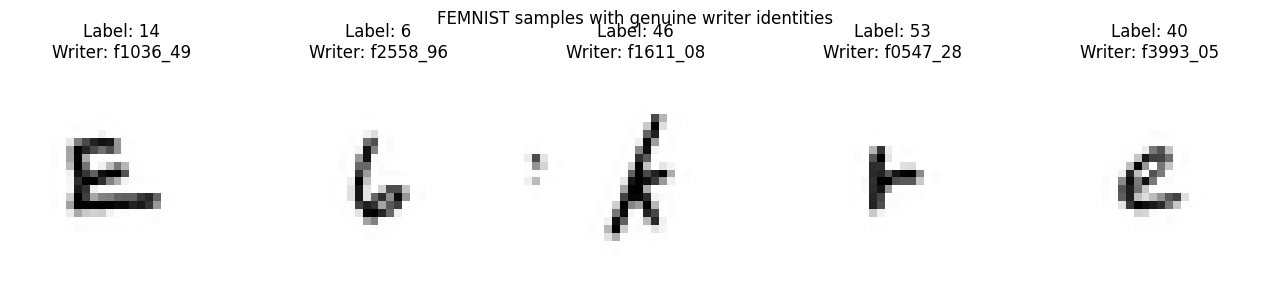

In [ ]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax in axes:
    subject = rng.choice(all_subjects)
    idx = rng.integers(0, len(femnist[subject]["y"]))
    ax.imshow(femnist[subject]["x"][idx, 0], cmap="gray")
    ax.set_title(f"Label: {femnist[subject]['y'][idx]}\n" f"Writer: {subject}")
    ax.axis("off")
plt.suptitle("FEMNIST samples with genuine writer identities")
plt.tight_layout()
plt.show()

In [ ]:
set_seed()
shuffled_subjects = all_subjects.copy()
random.shuffle(shuffled_subjects)
split_idx = int(round(MEMBER_FRACTION * len(shuffled_subjects)))
member_subjects = sorted(shuffled_subjects[:split_idx])
nonmember_subjects = sorted(shuffled_subjects[split_idx:])
member_federated_train = {}
member_attack_pool = {}
nonmember_attack_pool = {}
task_test_by_subject = {}
rng = np.random.default_rng(SEED)
for subject in member_subjects:
    x = femnist[subject]["x"]
    y = femnist[subject]["y"]
    perm = rng.permutation(len(y))
    cut1 = len(y) // 2
    train_idx = perm[:cut1]
    remain_idx = perm[cut1:]
    cut2 = len(remain_idx) // 2
    attack_idx = remain_idx[:cut2]
    test_idx = remain_idx[cut2:]
    if len(attack_idx) == 0:
        attack_idx = train_idx[-1:]
        train_idx = train_idx[:-1]
    member_federated_train[subject] = {
        "x": x[train_idx],
        "y": y[train_idx]
    }
    member_attack_pool[subject] = {
        "x": x[attack_idx],
        "y": y[attack_idx]
    }
    task_test_by_subject[subject] = {
        "x": x[test_idx],
        "y": y[test_idx]
    }
for subject in nonmember_subjects:
    x = femnist[subject]["x"]
    y = femnist[subject]["y"]
    nonmember_attack_pool[subject] = {
        "x": x,
        "y": y
    }

member_train_images = sum(
    len(v["y"])
    for v in member_federated_train.values()
)
member_attack_images = sum(
    len(v["y"])
    for v in member_attack_pool.values()
)
nonmember_images = sum(
    len(v["y"])
    for v in nonmember_attack_pool.values()
)

print("--- Subject-level split ---")
print(f"Member subjects: {len(member_subjects)}")
print(f"Non-member subjects: {len(nonmember_subjects)}")
print(f"Federated member records: {member_train_images:,}")
print(f"Held-out member attack records: {member_attack_images:,}")
print(f"Non-member attack records: {nonmember_images:,}")

assert set(member_subjects).isdisjoint(nonmember_subjects)
assert set(member_federated_train).isdisjoint(nonmember_attack_pool)

--- Subject-level split ---
Member subjects: 50
Non-member subjects: 50
Federated member records: 5,964
Held-out member attack records: 2,977
Non-member attack records: 12,003


In [ ]:
def partition_subjects_across_silos(subject_data: Dict[str, Dict[str, np.ndarray]], num_silos: int, seed: int,):
    rng_py = random.Random(seed)
    rng_np = np.random.default_rng(seed)
    silo_data = {f"Silo_{i}": {} for i in range(num_silos)}
    subject_to_silos: Dict[str, List[str]] = {}
    for subject, data in subject_data.items():
        k = rng_py.choices(SILOS_PER_SUBJECT_CHOICES, weights=SILOS_PER_SUBJECT_WEIGHTS, k=1,)[0]
        k = min(k, num_silos, len(data["y"]))
        selected_indices = rng_py.sample(range(num_silos), k=k)
        selected_silos = [f"Silo_{i}" for i in selected_indices]
        subject_to_silos[subject] = selected_silos
        perm = rng_np.permutation(len(data["y"]))
        index_splits = np.array_split(perm, k)
        for silo_name, indices in zip(selected_silos, index_splits):
            silo_data[silo_name][subject] = {
                "x": data["x"][indices],
                "y": data["y"][indices],
            }
    assigned_total = sum(
        len(subject_data_silo["y"])
        for silo in silo_data.values()
        for subject_data_silo in silo.values()
    )
    source_total = sum(len(v["y"]) for v in subject_data.values())
    assert assigned_total == source_total, "Every record must be assigned exactly once."
    assigned_subjects = {subject for silo in silo_data.values() for subject in silo}
    assert assigned_subjects == set(subject_data), "All member subjects must be assigned."
    assert assigned_subjects.isdisjoint(nonmember_subjects), "Non-members leaked into silos."
    return silo_data, subject_to_silos

silo_data, subject_to_silos = partition_subjects_across_silos(member_federated_train, NUM_SILOS, SEED,)

In [ ]:
images_per_silo = {
    silo: sum(len(v["y"]) for v in data.values())
    for silo, data in silo_data.items()
}
total_silo_images = sum(images_per_silo.values())
silo_share = {
    silo: 100.0 * count / total_silo_images
    for silo, count in images_per_silo.items()
}
silos_per_subject = pd.Series(
    {subject: len(silos) for subject, silos in subject_to_silos.items()},
    name="Number of silos",
)
single_silo_pct = 100.0 * (silos_per_subject == 1).mean()
multi_silo_pct = 100.0 * (silos_per_subject > 1).mean()
silo_stats = pd.DataFrame({
    "Silo": list(images_per_silo),
    "Images": list(images_per_silo.values()),
    "Share (%)": [silo_share[s] for s in images_per_silo],
})

print(silo_stats.to_string(index=False))
print(f"Subjects in one silo: {single_silo_pct:.2f}%")
print(f"Subjects in multiple silos: {multi_silo_pct:.2f}%")
print("Coefficient of variation of silo sizes:", silo_stats["Images"].std() / silo_stats["Images"].mean())

  Silo  Images  Share (%)
Silo_0     919  15.409121
Silo_1     500   8.383635
Silo_2     972  16.297787
Silo_3     698  11.703555
Silo_4     576   9.657948
Silo_5     589   9.875922
Silo_6     844  14.151576
Silo_7     866  14.520456
Subjects in one silo: 46.00%
Subjects in multiple silos: 54.00%
Coefficient of variation of silo sizes: 0.23854405646624935


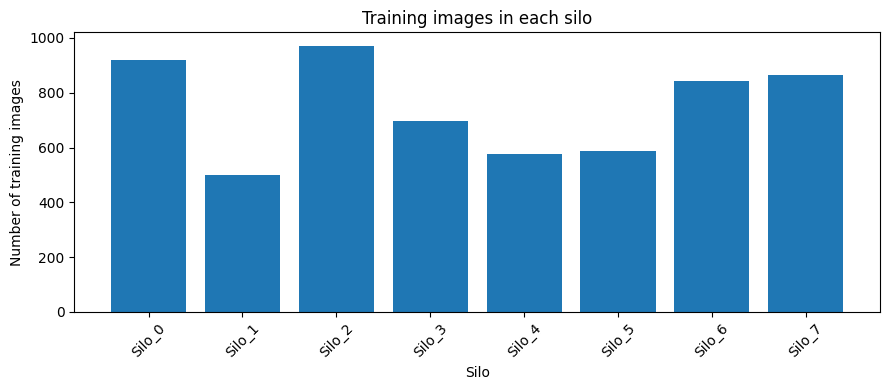

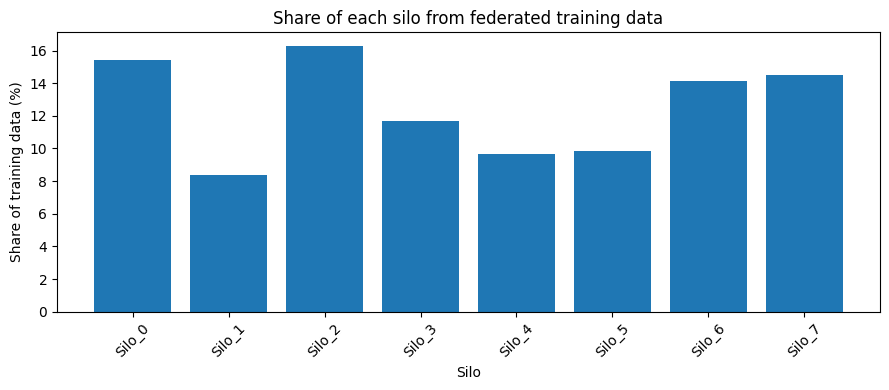

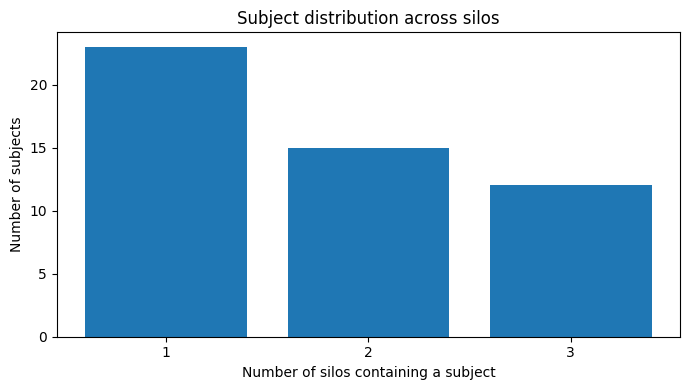

In [ ]:
plt.figure(figsize=(9, 4))
plt.bar(silo_stats["Silo"], silo_stats["Images"])
plt.xlabel("Silo")
plt.ylabel("Number of training images")
plt.title("Training images in each silo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(9, 4))
plt.bar(silo_stats["Silo"], silo_stats["Share (%)"])
plt.xlabel("Silo")
plt.ylabel("Share of training data (%)")
plt.title("Share of each silo from federated training data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 4))
counts = silos_per_subject.value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Number of silos containing a subject")
plt.ylabel("Number of subjects")
plt.title("Subject distribution across silos")
plt.tight_layout()
plt.show()

***Subsection 2: (Training the Federated Model)***

In [ ]:
class SubjectDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray, subject_ids: np.ndarray):
        self.x = torch.as_tensor(np.asarray(x), dtype=torch.uint8)
        if self.x.ndim == 3:
            self.x = self.x.unsqueeze(1)
        self.y = torch.as_tensor(y, dtype=torch.long)
        self.subject_ids = torch.as_tensor(subject_ids, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        image = self.x[idx].float() / 255.0
        return image, self.y[idx], self.subject_ids[idx]

global_subject_to_int = {s: i for i, s in enumerate(all_subjects)}

def flatten_subject_dict(subject_dict: Dict[str, Dict[str, np.ndarray]]):
    xs, ys, subject_ids = [], [], []
    for subject, data in subject_dict.items():
        n = len(data["y"])
        if n == 0:
            continue
        xs.append(data["x"])
        ys.append(data["y"])
        subject_ids.append(np.full(n, global_subject_to_int[subject], dtype=np.int64))
    if not xs:
        raise ValueError("Empty subject dictionary")
    return np.concatenate(xs), np.concatenate(ys), np.concatenate(subject_ids)

silo_datasets = {}
silo_loaders = {}
for silo, data in silo_data.items():
    x, y, sid = flatten_subject_dict(data)
    dataset = SubjectDataset(x, y, sid)
    silo_datasets[silo] = dataset
    silo_loaders[silo] = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False,)
x_test, y_test, sid_test = flatten_subject_dict(task_test_by_subject)
task_test_loader = DataLoader(SubjectDataset(x_test, y_test, sid_test), batch_size=BATCH_SIZE, shuffle=False,)

print("Silo sizes:", {k: len(v) for k, v in silo_datasets.items()})
print("Task test samples:", len(y_test))

Silo sizes: {'Silo_0': 919, 'Silo_1': 500, 'Silo_2': 972, 'Silo_3': 698, 'Silo_4': 576, 'Silo_5': 589, 'Silo_6': 844, 'Silo_7': 866}
Task test samples: 3004


In [ ]:
class FEMNISTCNN(nn.Module):
    def __init__(self, num_classes: int = 62):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 2048),
            nn.ReLU(),
            nn.Linear(2048, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

criterion = nn.CrossEntropyLoss()
criterion_none = nn.CrossEntropyLoss(reduction="none")

set_seed()
initial_model = FEMNISTCNN()
INITIAL_STATE = deepcopy(initial_model.state_dict())

In [ ]:
def local_train_plain(global_model: nn.Module, loader: DataLoader) -> nn.Module:
    model = FEMNISTCNN().to(DEVICE)
    model.load_state_dict(global_model.state_dict())
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    model.train()

    for _ in range(LOCAL_EPOCHS):
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    return model.cpu()

def fedavg_weighted(local_models: List[nn.Module], local_sizes: List[int]) -> nn.Module:
    if not local_models:
        raise ValueError("No local models supplied to FedAvg")
    weights = np.asarray(local_sizes, dtype=np.float64)
    weights = weights / weights.sum()
    averaged_state = {}
    state_dicts = [m.state_dict() for m in local_models]
    for key in state_dicts[0]:
        tensors = [state[key].detach().float() * float(w) for state, w in zip(state_dicts, weights)]
        averaged_state[key] = torch.stack(tensors, dim=0).sum(dim=0)
    global_model = FEMNISTCNN()
    global_model.load_state_dict(averaged_state)
    return global_model

def evaluate_model(model: nn.Module, loader: DataLoader = task_test_loader) -> Tuple[float, float]:
    model = model.to(DEVICE)
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss_sum += criterion(logits, y).item() * len(y)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += len(y)
    model.cpu()
    return correct / total, loss_sum / total

In [ ]:
def select_silos(round_index: int) -> List[str]:
    names = sorted(silo_loaders)
    number = max(1, math.ceil(CLIENT_FRACTION * len(names)))
    if number == len(names):
        return names
    rng = random.Random(SEED + round_index)
    return sorted(rng.sample(names, number))

def train_fedavg(rounds: int = NUM_ROUNDS, initial_state: Optional[dict] = None,):
    global_model = FEMNISTCNN()
    global_model.load_state_dict(INITIAL_STATE if initial_state is None else initial_state)
    round_models = [deepcopy(global_model)]
    history = []
    for round_idx in range(rounds):
        selected = select_silos(round_idx)
        local_models = []
        local_sizes = []
        for silo in selected:
            local_models.append(local_train_plain(global_model, silo_loaders[silo]))
            local_sizes.append(len(silo_datasets[silo]))
        global_model = fedavg_weighted(local_models, local_sizes)
        round_models.append(deepcopy(global_model))
        acc, loss = evaluate_model(global_model)
        history.append({
            "Round": round_idx + 1,
            "Accuracy": acc,
            "Loss": loss,
            "Participating silos": len(selected),
        })
        print(f"Round {round_idx + 1:03d}/{rounds}: accuracy={acc:.4f}, loss={loss:.4f}")
    return global_model, round_models, pd.DataFrame(history)

In [76]:
if RUN_BASELINE_TRAINING:
    global_model, round_models, baseline_history = train_fedavg()
    display(baseline_history.tail())
else:
    print("Baseline training skipped. Set RUN_BASELINE_TRAINING=True.")

Round 001/10: accuracy=0.0469, loss=3.7348
Round 002/10: accuracy=0.0513, loss=3.7407
Round 003/10: accuracy=0.0469, loss=3.7501
Round 004/10: accuracy=0.0483, loss=3.7770
Round 005/10: accuracy=0.0609, loss=3.7407
Round 006/10: accuracy=0.0945, loss=3.7593
Round 007/10: accuracy=0.0792, loss=3.7081
Round 008/10: accuracy=0.0762, loss=3.7029
Round 009/10: accuracy=0.1954, loss=3.6444
Round 010/10: accuracy=0.0699, loss=3.6271


,Round,Accuracy,Loss,Participating silos
5,6,0.094541,3.759259,8
6,7,0.079228,3.708096,8
7,8,0.076232,3.702913,8
8,9,0.195406,3.644350,8
9,10,0.069907,3.627146,8


In [ ]:
if RUN_BASELINE_TRAINING:
    plt.figure(figsize=(8, 4))
    plt.plot(baseline_history["Round"], baseline_history["Accuracy"], marker="o")
    plt.xlabel("Federated round")
    plt.ylabel("Task-test accuracy")
    plt.title("Global model accuracy across rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8, 4))
    plt.plot(baseline_history["Round"], baseline_history["Loss"], marker="o")
    plt.xlabel("Federated round")
    plt.ylabel("Task-test cross-entropy")
    plt.title("Global model loss across rounds")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    final_acc = baseline_history.iloc[-1]["Accuracy"]
    final_loss = baseline_history.iloc[-1]["Loss"]
    recent_improvement = baseline_history["Loss"].iloc[-5] - final_loss if len(baseline_history) >= 5 else np.nan
    print(f"Final global accuracy: {final_acc:.4f}")
    print(f"Final global loss: {final_loss:.4f}")
    print(f"Loss reduction over last five recorded rounds: {recent_improvement:.6f}")

***Subsection 3: (Evaluation of Membership Inference Attacks)***

In [ ]:
def sample_subject_records(pool: Dict[str, Dict[str, np.ndarray]], subjects: List[str], max_per_subject: int, seed: int,):
    rng = np.random.default_rng(seed)
    selected = {}
    for subject in subjects:
        data = pool[subject]
        n = min(max_per_subject, len(data["y"]))
        idx = rng.choice(len(data["y"]), size=n, replace=False)
        selected[subject] = {"x": data["x"][idx], "y": data["y"][idx]}
    return selected

def split_attack_subjects(member_subjects, nonmember_subjects, val_per_class, seed):
    rng = np.random.default_rng(seed)
    m = np.array(member_subjects)
    n = np.array(nonmember_subjects)
    rng.shuffle(m)
    rng.shuffle(n)
    max_val_m = max(1, len(m) // 2)
    max_val_n = max(1, len(n) // 2)
    v = min(val_per_class, max_val_m, max_val_n)
    return {
        "validation_member": sorted(m[:v].tolist()),
        "validation_nonmember": sorted(n[:v].tolist()),
        "evaluation_member": sorted(m[v:].tolist()),
        "evaluation_nonmember": sorted(n[v:].tolist()),
    }

subject_attack_split = split_attack_subjects(member_subjects, nonmember_subjects, ATTACK_VALIDATION_SUBJECTS_PER_CLASS, SEED,)
member_attack_samples = sample_subject_records(member_attack_pool, member_subjects, MAX_ATTACK_SAMPLES_PER_SUBJECT, SEED + 1,)
nonmember_attack_samples = sample_subject_records(nonmember_attack_pool, nonmember_subjects, MAX_ATTACK_SAMPLES_PER_SUBJECT, SEED + 2,)
print({k: len(v) for k, v in subject_attack_split.items()})

{'validation_member': 25, 'validation_nonmember': 25, 'evaluation_member': 25, 'evaluation_nonmember': 25}


In [ ]:
def subject_loss_matrix(models: List[nn.Module], member_samples: Dict[str, Dict[str, np.ndarray]], nonmember_samples: Dict[str, Dict[str, np.ndarray]],):
    ordered_subjects = sorted(member_samples) + sorted(nonmember_samples)
    labels = np.array([1] * len(member_samples) + [0] * len(nonmember_samples), dtype=np.int64,)
    combined = {**member_samples, **nonmember_samples}
    x, y, sid_global = flatten_subject_dict({s: combined[s] for s in ordered_subjects})
    local_subject_index = {global_subject_to_int[s]: i for i, s in enumerate(ordered_subjects)}
    sid_local = np.array([local_subject_index[int(v)] for v in sid_global], dtype=np.int64)
    loader = DataLoader(SubjectDataset(x, y, sid_local), batch_size=BATCH_SIZE, shuffle=False,)
    matrix = np.zeros((len(ordered_subjects), len(models)), dtype=np.float64)
    counts = np.zeros(len(ordered_subjects), dtype=np.int64)
    for _, _, sid in loader:
        counts += np.bincount(sid.numpy(), minlength=len(ordered_subjects))
    for model_idx, model in enumerate(models):
        sums = np.zeros(len(ordered_subjects), dtype=np.float64)
        model = model.to(DEVICE)
        model.eval()
        with torch.no_grad():
            for xb, yb, sid in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                losses = criterion_none(model(xb), yb).cpu().numpy()
                sums += np.bincount(
                    sid.numpy(),
                    weights=losses,
                    minlength=len(ordered_subjects),
                )
        model.cpu()
        matrix[:, model_idx] = sums
    return ordered_subjects, labels, matrix

def best_integer_threshold(scores: np.ndarray, labels: np.ndarray):
    candidates = np.arange(0, int(scores.max()) + 2)
    best = None
    for threshold in candidates:
        pred = (scores >= threshold).astype(int)
        metrics = (
            f1_score(labels, pred, zero_division=0),
            accuracy_score(labels, pred),
            threshold,
        )
        if best is None or metrics[:2] > best[:2]:
            best = metrics
    return int(best[2])

def metric_dict(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def evaluate_loss_across_rounds(models: List[nn.Module], split: dict = subject_attack_split,):
    subjects, labels, losses = subject_loss_matrix(models, member_attack_samples, nonmember_attack_samples,)
    subject_to_row = {s: i for i, s in enumerate(subjects)}
    val_subjects = split["validation_member"] + split["validation_nonmember"]
    eval_subjects = split["evaluation_member"] + split["evaluation_nonmember"]
    val_idx = np.array([subject_to_row[s] for s in val_subjects])
    eval_idx = np.array([subject_to_row[s] for s in eval_subjects])
    decreases = (losses[:, 1:] < losses[:, :-1]).astype(np.int64)
    cumulative_scores = np.cumsum(decreases, axis=1)
    rows = []
    for round_idx in range(cumulative_scores.shape[1]):
        val_scores = cumulative_scores[val_idx, round_idx]
        threshold = best_integer_threshold(val_scores, labels[val_idx])
        pred = (cumulative_scores[eval_idx, round_idx] >= threshold).astype(int)
        metrics = metric_dict(labels[eval_idx], pred)
        rows.append({
            "Round": round_idx + 1,
            "Threshold": threshold,
            **metrics,
        })
    return pd.DataFrame(rows), {
        "subjects": subjects,
        "labels": labels,
        "loss_matrix": losses,
        "score_matrix": cumulative_scores,
        "evaluation_indices": eval_idx,
    }

,Round,Threshold,Accuracy,Precision,Recall,F1
5,6,3,0.54,0.521739,0.96,0.676056
6,7,4,0.50,0.500000,0.84,0.626866
7,8,4,0.54,0.520833,1.00,0.684932
8,9,5,0.52,0.511111,0.92,0.657143
9,10,0,0.50,0.500000,1.00,0.666667


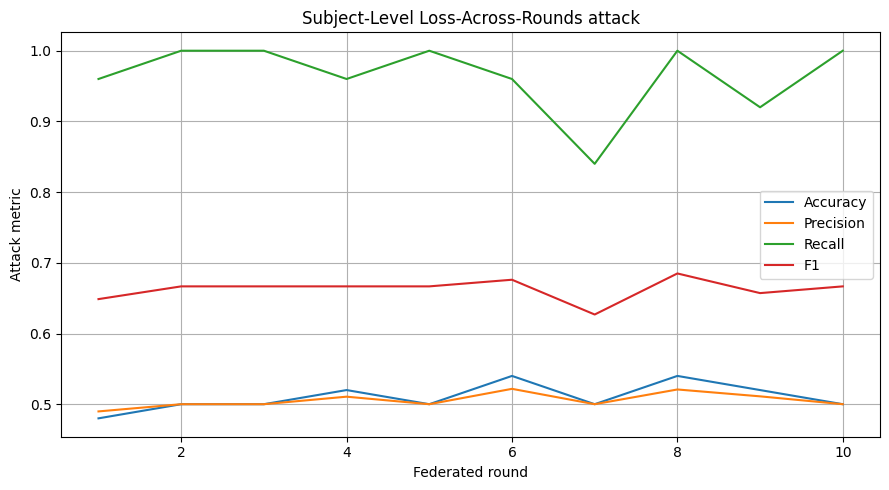

In [ ]:
if RUN_BASELINE_TRAINING:
    subject_attack_history, subject_attack_details = evaluate_loss_across_rounds(round_models)
    subject_metrics = subject_attack_history.iloc[-1].to_dict()
    display(subject_attack_history.tail())
    plt.figure(figsize=(9, 5))
    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        plt.plot(subject_attack_history["Round"], subject_attack_history[metric], label=metric)
    plt.xlabel("Federated round")
    plt.ylabel("Attack metric")
    plt.title("Subject-Level Loss-Across-Rounds attack")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
if RUN_BASELINE_TRAINING:
    details = subject_attack_details
    losses = details["loss_matrix"]
    labels = details["labels"]
    eval_idx = details["evaluation_indices"]
    member_mean = losses[eval_idx][labels[eval_idx] == 1].mean(axis=0)
    nonmember_mean = losses[eval_idx][labels[eval_idx] == 0].mean(axis=0)
    plt.figure(figsize=(9, 5))
    plt.plot(range(len(member_mean)), member_mean, label="Member subjects")
    plt.plot(range(len(nonmember_mean)), nonmember_mean, label="Non-member subjects")
    plt.xlabel("Model state (0 = before training)")
    plt.ylabel("Mean summed cross-entropy")
    plt.title("Subject loss trajectories")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def sample_record_attack_data(seed: int = SEED):
    rng = np.random.default_rng(seed)
    member_x = np.concatenate([v["x"] for v in member_federated_train.values()])
    member_y = np.concatenate([v["y"] for v in member_federated_train.values()])
    nonmember_x = np.concatenate([v["x"] for v in nonmember_attack_pool.values()])
    nonmember_y = np.concatenate([v["y"] for v in nonmember_attack_pool.values()])
    n = min(
        MAX_RECORD_ATTACK_SAMPLES_PER_CLASS,
        len(member_y),
        len(nonmember_y),
    )
    m_idx = rng.choice(len(member_y), size=n, replace=False)
    n_idx = rng.choice(len(nonmember_y), size=n, replace=False)
    x = np.concatenate([member_x[m_idx], nonmember_x[n_idx]])
    y_class = np.concatenate([member_y[m_idx], nonmember_y[n_idx]])
    membership = np.concatenate([np.ones(n), np.zeros(n)]).astype(np.int64)
    indices = np.arange(len(membership))
    calibration_idx, evaluation_idx = train_test_split(
        indices,
        test_size=0.70,
        random_state=SEED,
        stratify=membership,
    )
    return x, y_class, membership, calibration_idx, evaluation_idx

record_x, record_y, record_membership, record_cal_idx, record_eval_idx = sample_record_attack_data()
record_loader = DataLoader(
    TensorDataset(
        torch.as_tensor(record_x, dtype=torch.float32).div(255.0),
        torch.as_tensor(record_y, dtype=torch.long),
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [ ]:
def record_loss_matrix(models: List[nn.Module]):
    matrix = np.zeros((len(record_membership), len(models)), dtype=np.float64)
    for model_idx, model in enumerate(models):
        model = model.to(DEVICE)
        model.eval()
        offset = 0
        with torch.no_grad():
            for xb, yb in record_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                losses = criterion_none(model(xb), yb).cpu().numpy()
                matrix[offset:offset + len(losses), model_idx] = losses
                offset += len(losses)
        model.cpu()
    return matrix

def best_loss_threshold(losses: np.ndarray, labels: np.ndarray):
    unique = np.unique(losses)
    if len(unique) > 1000:
        candidates = np.quantile(unique, np.linspace(0, 1, 1001))
    else:
        candidates = unique
    candidates = np.concatenate(([-np.inf], candidates, [np.inf]))
    best = None
    for threshold in candidates:
        pred = (losses <= threshold).astype(int)
        metrics = (
            f1_score(labels, pred, zero_division=0),
            accuracy_score(labels, pred),
            float(threshold),
        )
        if best is None or metrics[:2] > best[:2]:
            best = metrics
    return best[2]


def evaluate_record_attack(models: List[nn.Module]):
    losses = record_loss_matrix(models)
    rows = []
    for model_idx in range(1, losses.shape[1]):
        threshold = best_loss_threshold(
            losses[record_cal_idx, model_idx],
            record_membership[record_cal_idx],
        )
        pred = (losses[record_eval_idx, model_idx] <= threshold).astype(int)
        metrics = metric_dict(record_membership[record_eval_idx], pred)
        rows.append({
            "Round": model_idx,
            "Threshold": threshold,
            **metrics,
        })

    return pd.DataFrame(rows), losses

,Round,Threshold,Accuracy,Precision,Recall,F1
5,6,5.282581,0.500120,0.50006,0.998802,0.666454
6,7,6.850316,0.500359,0.50018,0.999521,0.666720
7,8,5.553721,0.500240,0.50012,0.999521,0.666667
8,9,6.752085,0.500359,0.50018,0.999760,0.666773
9,10,6.137444,0.500479,0.50024,1.000000,0.666880


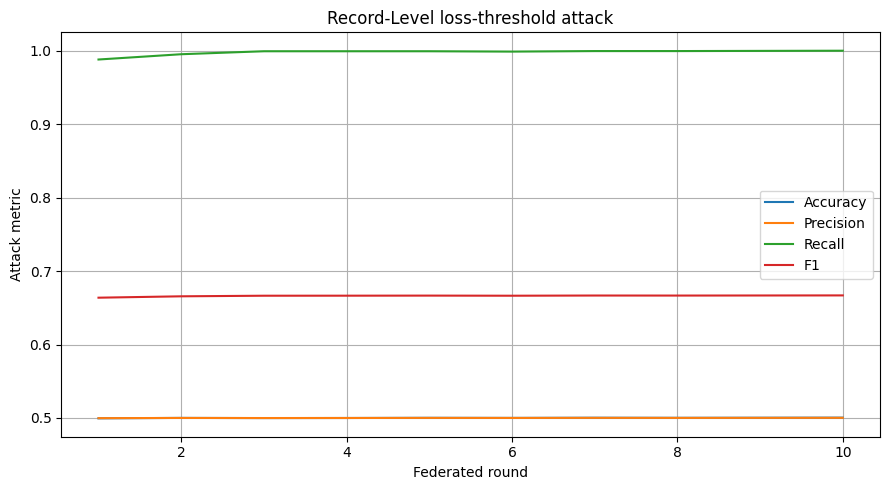

In [ ]:
if RUN_BASELINE_TRAINING:
    record_attack_history, baseline_record_losses = evaluate_record_attack(round_models)
    record_metrics = record_attack_history.iloc[-1].to_dict()
    display(record_attack_history.tail())
    plt.figure(figsize=(9, 5))
    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        plt.plot(record_attack_history["Round"], record_attack_history[metric], label=metric)
    plt.xlabel("Federated round")
    plt.ylabel("Attack metric")
    plt.title("Record-Level loss-threshold attack")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
if RUN_BASELINE_TRAINING:
    attack_comparison = pd.DataFrame([
        {
            "Attack": "Subject Loss-Across-Rounds",
            "Accuracy": subject_metrics["Accuracy"],
            "Precision": subject_metrics["Precision"],
            "Recall": subject_metrics["Recall"],
            "F1": subject_metrics["F1"],
        },
        {
            "Attack": "Record Loss-Threshold",
            "Accuracy": record_metrics["Accuracy"],
            "Precision": record_metrics["Precision"],
            "Recall": record_metrics["Recall"],
            "F1": record_metrics["F1"],
        },
    ])
    display(attack_comparison)

***Subsection 4: (Defense Based on Differential Privacy)***

In [ ]:
def require_opacus():
    if not OPACUS_AVAILABLE:
        raise ImportError(
            "Opacus is required for this section. Run `%pip install opacus`, "
            "restart the kernel, and execute the notebook from the beginning."
        )

def clone_plain_model(model: nn.Module) -> nn.Module:
    if hasattr(model, "_module"):
        state = model._module.state_dict()
    else:
        state = model.state_dict()
    plain = FEMNISTCNN()
    plain.load_state_dict(state)
    return plain

def unwrap_grad_sample_model(model: nn.Module) -> nn.Module:
    if hasattr(model, "to_standard_module"):
        plain = model.to_standard_module()
        return plain.cpu()
    if hasattr(model, "remove_hooks"):
        model.remove_hooks()
    plain = FEMNISTCNN()
    plain.load_state_dict(model._module.state_dict())
    return plain.cpu()

def estimate_epsilon(noise_multiplier: float, sample_rate: float, steps: int, delta: float) -> float:
    require_opacus()
    accountant = RDPAccountant()
    for _ in range(int(steps)):
        accountant.step(
            noise_multiplier=float(noise_multiplier),
            sample_rate=float(sample_rate),
        )
    return float(accountant.get_epsilon(delta=float(delta)))

def calibrate_noise_multiplier(target_epsilon: float, target_delta: float, sample_rate: float, steps: int,) -> float:
    require_opacus()
    return float(get_noise_multiplier(
        target_epsilon=float(target_epsilon),
        target_delta=float(target_delta),
        sample_rate=float(sample_rate),
        steps=int(steps),
        accountant="rdp",
    ))

In [ ]:
def build_record_dp_privacy_plan(rounds: int, target_epsilon: float, target_delta: float, clipping_norm: float,):
    plan = {}
    for silo, dataset in silo_datasets.items():
        n = len(dataset)
        steps_per_epoch = math.ceil(n / BATCH_SIZE)
        total_steps = rounds * LOCAL_EPOCHS * steps_per_epoch
        q = min(1.0, BATCH_SIZE / n)
        sigma = calibrate_noise_multiplier(target_epsilon, target_delta, q, total_steps)
        achieved = estimate_epsilon(sigma, q, total_steps, target_delta)
        plan[silo] = {
            "sample_rate": q,
            "steps": total_steps,
            "noise_multiplier": sigma,
            "epsilon": achieved,
            "delta": target_delta,
            "clipping_norm": clipping_norm,
        }
    return plan

def local_train_record_dp(global_model: nn.Module, loader: DataLoader, noise_multiplier: float, clipping_norm: float,):
    require_opacus()
    model = clone_plain_model(global_model).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    privacy_engine = PrivacyEngine(accountant="rdp", secure_mode=False,)
    private_model, private_optimizer, private_loader = (
        privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=loader,
            noise_multiplier=float(noise_multiplier),
            max_grad_norm=float(clipping_norm),
            poisson_sampling=True,
        )
    )
    private_model.train()
    for _ in range(LOCAL_EPOCHS):
        with BatchMemoryManager(
            data_loader=private_loader,
            max_physical_batch_size=DP_MAX_PHYSICAL_BATCH_SIZE,
            optimizer=private_optimizer,
        ) as memory_safe_loader:
            for xb, yb, _ in memory_safe_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                loss = criterion(private_model(xb), yb)
                loss.backward()
                private_optimizer.step()
                private_optimizer.zero_grad(set_to_none=True)
    plain_model = unwrap_grad_sample_model(private_model)
    del private_model
    del private_optimizer
    del private_loader
    del privacy_engine
    del model
    del optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return plain_model


def train_record_dp_federated(rounds: int = NUM_ROUNDS, target_epsilon: float = TARGET_EPSILON, target_delta: float = TARGET_DELTA,
                             clipping_norm: float = MAX_GRAD_NORM, fixed_plan: Optional[dict] = None,):
    plan = fixed_plan or build_record_dp_privacy_plan(rounds, target_epsilon, target_delta, clipping_norm)
    global_model = FEMNISTCNN()
    global_model.load_state_dict(INITIAL_STATE)
    models = [deepcopy(global_model)]
    history = []
    for round_idx in range(rounds):
        selected = select_silos(round_idx)
        local_models, local_sizes = [], []
        for silo in selected:
            local_models.append(local_train_record_dp(
                global_model,
                silo_loaders[silo],
                plan[silo]["noise_multiplier"],
                clipping_norm,
            ))
            local_sizes.append(len(silo_datasets[silo]))
        global_model = fedavg_weighted(local_models, local_sizes)
        models.append(deepcopy(global_model))
        acc, loss = evaluate_model(global_model)
        history.append({"Round": round_idx + 1, "Accuracy": acc, "Loss": loss})
        print(f"Record-DP round {round_idx + 1:03d}/{rounds}: accuracy={acc:.4f}, loss={loss:.4f}")
    return global_model, models, pd.DataFrame(history), pd.DataFrame(plan).T.reset_index(names="Silo")

In [ ]:
OPACUS_AVAILABLE = True
print("Opacus version:", opacus.__version__)
print("PrivacyEngine available:", PrivacyEngine is not None)
print("GradSampleModule available:", GradSampleModule is not None)
print("RDPAccountant available:", RDPAccountant is not None)
print("get_noise_multiplier callable:", callable(get_noise_multiplier))

assert callable(get_noise_multiplier), "get_noise_multiplier was not imported correctly."

In [ ]:
from opacus.utils.batch_memory_manager import BatchMemoryManager
DP_MAX_PHYSICAL_BATCH_SIZE = 16
SUBJECT_DP_BATCH_SIZE = 16
print("Logical DP batch size:", BATCH_SIZE)
print("Physical DP batch size:", DP_MAX_PHYSICAL_BATCH_SIZE)

In [ ]:
sys.last_traceback = None
sys.last_value = None
sys.last_type = None

for variable_name in [
    "record_dp_model",
    "record_dp_round_models",
    "record_dp_history",
    "record_dp_privacy",
]:
    globals().pop(variable_name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    print(f"GPU free memory: "
        f"{free_bytes / 1024**3:.2f} / "
        f"{total_bytes / 1024**3:.2f} GiB"
    )
    print("PyTorch allocated:",f"{torch.cuda.memory_allocated() / 1024**3:.2f} GiB",)

In [ ]:
if RUN_RECORD_DP:
    record_dp_model, record_dp_round_models, record_dp_history, record_dp_privacy = (train_record_dp_federated())
    display(record_dp_privacy)
    display(record_dp_history.tail())
else:
    print("Record-level DP skipped.")

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Record-DP round 001/10: accuracy=0.0136, loss=4.1018
Record-DP round 002/10: accuracy=0.0589, loss=4.0792
Record-DP round 003/10: accuracy=0.0379, loss=4.0556
Record-DP round 004/10: accuracy=0.0379, loss=4.0308
Record-DP round 005/10: accuracy=0.0379, loss=4.0066
Record-DP round 006/10: accuracy=0.0379, loss=3.9811
Record-DP round 007/10: accuracy=0.0379, loss=3.9569
Record-DP round 008/10: accuracy=0.0379, loss=3.9319
Record-DP round 009/10: accuracy=0.0379, loss=3.9072
Record-DP round 010/10: accuracy=0.0379, loss=3.8846


,Silo,sample_rate,steps,noise_multiplier,epsilon,delta,clipping_norm
0,Silo_0,0.557127,20.0,3.095703,3.999851,0.00001,1.0
1,Silo_1,1.000000,10.0,3.662109,3.998067,0.00001,1.0
2,Silo_2,0.526749,20.0,2.958984,3.991214,0.00001,1.0
3,Silo_3,0.733524,20.0,3.925781,3.996047,0.00001,1.0
4,Silo_4,0.888889,20.0,4.658203,3.995291,0.00001,1.0
5,Silo_5,0.869270,20.0,4.570312,3.990611,0.00001,1.0
6,Silo_6,0.606635,20.0,3.330078,3.995744,0.00001,1.0
7,Silo_7,0.591224,20.0,3.256836,3.997221,0.00001,1.0


,Round,Accuracy,Loss
5,6,0.037949,3.981087
6,7,0.037949,3.956919
7,8,0.037949,3.931903
8,9,0.037949,3.907183
9,10,0.037949,3.884594


In [ ]:
def max_records_of_one_subject_in_silo(silo: str) -> int:
    return max(len(v["y"]) for v in silo_data[silo].values())

def build_subject_dp_privacy_plan(rounds: int, global_target_epsilon: float, global_target_delta: float, clipping_norm: float, reuse_noise_multipliers: Optional[dict] = None,):
    max_silos_per_subject = max(len(v) for v in subject_to_silos.values())
    local_epsilon = global_target_epsilon / max_silos_per_subject
    local_delta = global_target_delta / max_silos_per_subject
    plan = {}
    for silo, dataset in silo_datasets.items():
        n = len(dataset)
        k = max_records_of_one_subject_in_silo(silo)
        q_subject = min(1.0, (k * SUBJECT_DP_BATCH_SIZE) / n)
        steps_per_epoch = math.ceil(n / SUBJECT_DP_BATCH_SIZE)
        total_steps = rounds * LOCAL_EPOCHS * steps_per_epoch
        if reuse_noise_multipliers is None:
            sigma = calibrate_noise_multiplier(local_epsilon, local_delta, q_subject, total_steps,)
        else:
            sigma = float(reuse_noise_multipliers[silo])
        local_achieved = estimate_epsilon(sigma, q_subject, total_steps, local_delta)
        plan[silo] = {
            "records": n,
            "max_records_per_subject_k": k,
            "subject_sample_rate": q_subject,
            "steps": total_steps,
            "noise_multiplier": sigma,
            "local_epsilon": local_achieved,
            "local_delta": local_delta,
            "conservative_global_epsilon": max_silos_per_subject * local_achieved,
            "global_delta_bound": max_silos_per_subject * local_delta,
            "clipping_norm": clipping_norm,
        }
    return plan

def _grad_sample_tensor(parameter: torch.nn.Parameter) -> torch.Tensor:
    gs = parameter.grad_sample
    if isinstance(gs, list):
        gs = torch.cat(gs, dim=0)
    return gs

def local_train_higradavg(global_model: nn.Module, dataset: Dataset, noise_multiplier: float, clipping_norm: float,):
    require_opacus()
    loader = DataLoader(
        dataset,
        batch_size=SUBJECT_DP_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )
    base_model = clone_plain_model(global_model).to(DEVICE)
    model = GradSampleModule(base_model, batch_first=True, loss_reduction="mean",)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    model.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb, subject_ids in loader:
            xb, yb, subject_ids = xb.to(DEVICE), yb.to(DEVICE), subject_ids.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb, reduction="mean")
            loss.backward()
            params = [p for p in model.parameters() if getattr(p, "grad_sample", None) is not None]
            grad_samples = [_grad_sample_tensor(p) for p in params]
            batch_n = len(yb)
            per_parameter_norms = torch.stack([
                gs.reshape(batch_n, -1).norm(2, dim=1)
                for gs in grad_samples
            ], dim=1)
            per_record_norm = per_parameter_norms.norm(2, dim=1)
            clip_factor = (clipping_norm / (per_record_norm + 1e-12)).clamp(max=1.0)
            unique_subjects = torch.unique(subject_ids)
            number_of_subjects = max(1, len(unique_subjects))
            for parameter, gs in zip(params, grad_samples):
                shape = [batch_n] + [1] * (gs.ndim - 1)
                clipped = gs * clip_factor.view(shape)
                subject_averages = []
                for subject_id in unique_subjects:
                    mask = subject_ids == subject_id
                    subject_averages.append(clipped[mask].mean(dim=0))
                average_of_averages = torch.stack(subject_averages, dim=0).mean(dim=0)
                noise_std = noise_multiplier * clipping_norm / number_of_subjects
                parameter.grad = average_of_averages + torch.randn_like(average_of_averages) * noise_std
                parameter.grad_sample = None
            optimizer.step()
    return unwrap_grad_sample_model(model)


def train_subject_dp_federated(
    rounds: int = NUM_ROUNDS,
    target_epsilon: float = TARGET_EPSILON,
    target_delta: float = TARGET_DELTA,
    clipping_norm: float = MAX_GRAD_NORM,
    reuse_noise_multipliers: Optional[dict] = None,
):
    plan = build_subject_dp_privacy_plan(
        rounds,
        target_epsilon,
        target_delta,
        clipping_norm,
        reuse_noise_multipliers=reuse_noise_multipliers,
    )
    global_model = FEMNISTCNN()
    global_model.load_state_dict(INITIAL_STATE)
    models = [deepcopy(global_model)]
    history = []
    for round_idx in range(rounds):
        selected = select_silos(round_idx)
        local_models, local_sizes = [], []
        for silo in selected:
            local_models.append(local_train_higradavg(
                global_model,
                silo_datasets[silo],
                plan[silo]["noise_multiplier"],
                clipping_norm,
            ))
            local_sizes.append(len(silo_datasets[silo]))
        global_model = fedavg_weighted(local_models, local_sizes)
        models.append(deepcopy(global_model))
        acc, loss = evaluate_model(global_model)
        history.append({"Round": round_idx + 1, "Accuracy": acc, "Loss": loss})
        print(f"Subject-DP round {round_idx + 1:03d}/{rounds}: accuracy={acc:.4f}, loss={loss:.4f}")
    return global_model, models, pd.DataFrame(history), pd.DataFrame(plan).T.reset_index(names="Silo")

In [ ]:
if RUN_SUBJECT_DP:
    subject_dp_model, subject_dp_round_models, subject_dp_history, subject_dp_privacy = train_subject_dp_federated()
    display(subject_dp_privacy)
    display(subject_dp_history.tail())
else:
    print("Subject-level DP skipped.")

In [ ]:
def evaluate_all_attacks_for_method(method_name: str, models: List[nn.Module], model_history: pd.DataFrame):
    subject_hist, _ = evaluate_loss_across_rounds(models)
    record_hist, _ = evaluate_record_attack(models)
    final_subject = subject_hist.iloc[-1]
    final_record = record_hist.iloc[-1]
    final_model = model_history.iloc[-1]
    summary = {
        "Method": method_name,
        "Model accuracy": final_model["Accuracy"],
        "Model loss": final_model["Loss"],
        "Subject attack accuracy": final_subject["Accuracy"],
        "Subject attack precision": final_subject["Precision"],
        "Subject attack recall": final_subject["Recall"],
        "Subject attack F1": final_subject["F1"],
        "Record attack accuracy": final_record["Accuracy"],
        "Record attack precision": final_record["Precision"],
        "Record attack recall": final_record["Recall"],
        "Record attack F1": final_record["F1"],
    }
    return summary, subject_hist, record_hist

method_summaries = []
attack_histories = {}

if RUN_BASELINE_TRAINING:
    summary, s_hist, r_hist = evaluate_all_attacks_for_method("FedAvg (No DP)", round_models, baseline_history)
    method_summaries.append(summary)
    attack_histories["FedAvg (No DP)"] = (s_hist, r_hist)

if RUN_RECORD_DP:
    summary, s_hist, r_hist = evaluate_all_attacks_for_method("Record-Level DP-SGD", record_dp_round_models, record_dp_history)
    method_summaries.append(summary)
    attack_histories["Record-Level DP-SGD"] = (s_hist, r_hist)

if RUN_SUBJECT_DP:
    summary, s_hist, r_hist = evaluate_all_attacks_for_method("Subject-Level HiGradAvgDP", subject_dp_round_models, subject_dp_history)
    method_summaries.append(summary)
    attack_histories["Subject-Level HiGradAvgDP"] = (s_hist, r_hist)
tradeoff_table = pd.DataFrame(method_summaries)
display(tradeoff_table)

,Method,Model accuracy,Model loss,Subject attack accuracy,Subject attack precision,Subject attack recall,Subject attack F1,Record attack accuracy,Record attack precision,Record attack recall,Record attack F1
0,FedAvg (No DP),0.069907,3.627146,0.5,0.5,1.0,0.666667,0.500479,0.50024,1.000000,0.666880
1,Record-Level DP-SGD,0.037949,3.884594,0.5,0.5,1.0,0.666667,0.499880,0.49994,0.999760,0.666560
2,Subject-Level HiGradAvgDP,0.052929,4.109882,0.5,0.5,1.0,0.666667,0.500479,0.50024,0.998084,0.666453


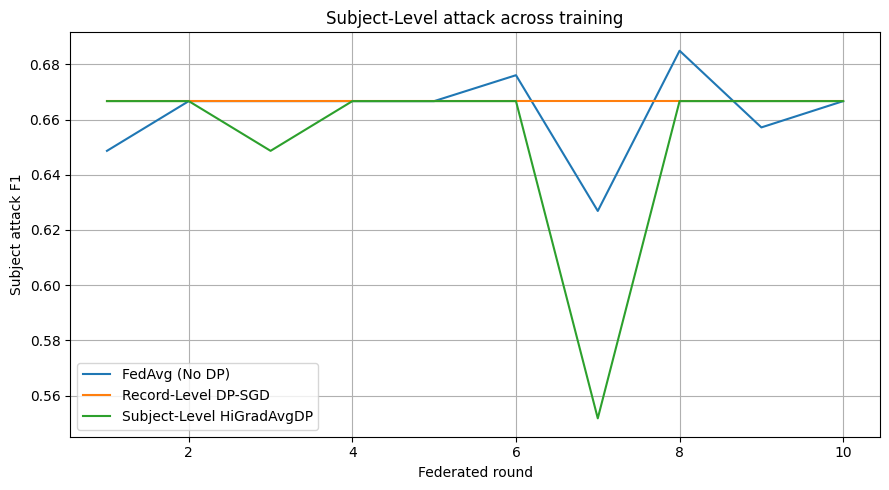

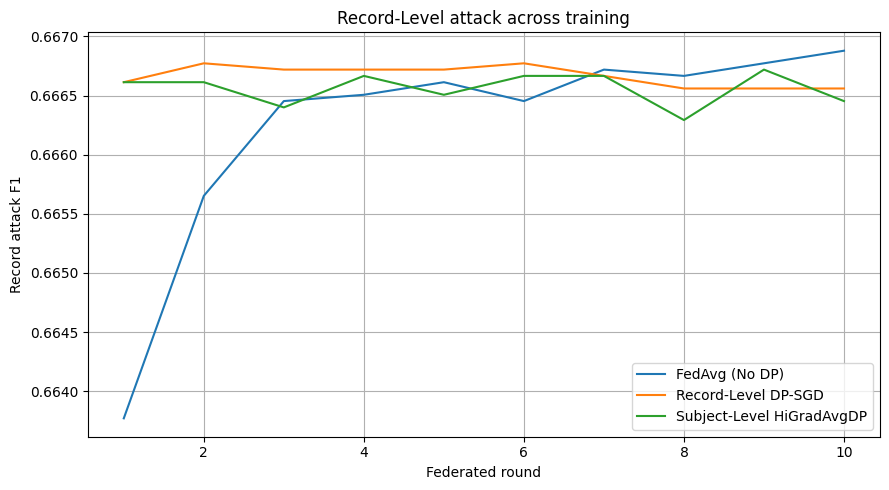

In [ ]:
if attack_histories:
    plt.figure(figsize=(9, 5))
    for method, (subject_hist, _) in attack_histories.items():
        plt.plot(subject_hist["Round"], subject_hist["F1"], label=method)
    plt.xlabel("Federated round")
    plt.ylabel("Subject attack F1")
    plt.title("Subject-Level attack across training")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(9, 5))
    for method, (_, record_hist) in attack_histories.items():
        plt.plot(record_hist["Round"], record_hist["F1"], label=method)
    plt.xlabel("Federated round")
    plt.ylabel("Record attack F1")
    plt.title("Record-Level attack across training")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def final_subject_attack_f1(models: List[nn.Module]) -> float:
    hist, _ = evaluate_loss_across_rounds(models)
    return float(hist.iloc[-1]["F1"])

def privacy_summary_from_plan(plan_df: pd.DataFrame):
    return {
        "Max local epsilon": float(plan_df["local_epsilon"].max()),
        "Conservative global epsilon": float(plan_df["conservative_global_epsilon"].max()),
        "Delta bound": float(plan_df["global_delta_bound"].max()),
        "Noise multiplier min": float(plan_df["noise_multiplier"].min()),
        "Noise multiplier max": float(plan_df["noise_multiplier"].max()),
    }

sensitivity_results = []
if RUN_SENSITIVITY:
    require_opacus()
    baseline_plan = build_subject_dp_privacy_plan(NUM_ROUNDS, TARGET_EPSILON, TARGET_DELTA, MAX_GRAD_NORM)
    baseline_sigmas = {silo: cfg["noise_multiplier"] for silo, cfg in baseline_plan.items()}
    experiments = [
        {
            "Name": "Double epsilon",
            "Rounds": NUM_ROUNDS,
            "Target epsilon": 2 * TARGET_EPSILON,
            "Clipping norm": MAX_GRAD_NORM,
            "Reuse sigma": None,
        },
        {
            "Name": "Half clipping norm",
            "Rounds": NUM_ROUNDS,
            "Target epsilon": TARGET_EPSILON,
            "Clipping norm": MAX_GRAD_NORM / 2,
            "Reuse sigma": baseline_sigmas,
        },
        {
            "Name": "Double rounds, fixed sigma",
            "Rounds": 2 * NUM_ROUNDS,
            "Target epsilon": TARGET_EPSILON,
            "Clipping norm": MAX_GRAD_NORM,
            "Reuse sigma": baseline_sigmas,
        },
    ]

    for exp in experiments:
        model, models, history, privacy = train_subject_dp_federated(
            rounds=exp["Rounds"],
            target_epsilon=exp["Target epsilon"],
            target_delta=TARGET_DELTA,
            clipping_norm=exp["Clipping norm"],
            reuse_noise_multipliers=exp["Reuse sigma"],
        )
        p = privacy_summary_from_plan(privacy)
        sensitivity_results.append({
            "Experiment": exp["Name"],
            "Rounds": exp["Rounds"],
            "Target epsilon": exp["Target epsilon"],
            "Final epsilon": p["Conservative global epsilon"],
            "Delta": p["Delta bound"],
            "Clipping norm": exp["Clipping norm"],
            "Noise multiplier min": p["Noise multiplier min"],
            "Noise multiplier max": p["Noise multiplier max"],
            "Final model accuracy": float(history.iloc[-1]["Accuracy"]),
            "Subject attack F1": final_subject_attack_f1(models),
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
if len(sensitivity_df):
    display(sensitivity_df)
else:
    print("Sensitivity experiments skipped. Set RUN_SENSITIVITY=True for the final run.")

Sensitivity experiments skipped. Set RUN_SENSITIVITY=True for the final run.


In [ ]:
final_rows = []
if RUN_BASELINE_TRAINING:
    row = tradeoff_table[tradeoff_table["Method"] == "FedAvg (No DP)"].iloc[0].to_dict()
    row.update({
        "Epsilon": np.inf,
        "Delta": 0.0,
        "Clipping norm": np.nan,
        "Noise multiplier range": "None",
    })
    final_rows.append(row)
if RUN_RECORD_DP:
    row = tradeoff_table[tradeoff_table["Method"] == "Record-Level DP-SGD"].iloc[0].to_dict()
    row.update({
        "Epsilon": float(record_dp_privacy["epsilon"].max()),
        "Delta": TARGET_DELTA,
        "Clipping norm": MAX_GRAD_NORM,
        "Noise multiplier range": (
            f"{record_dp_privacy['noise_multiplier'].min():.4f}–"
            f"{record_dp_privacy['noise_multiplier'].max():.4f}"
        ),
    })
    final_rows.append(row)
if RUN_SUBJECT_DP:
    row = tradeoff_table[tradeoff_table["Method"] == "Subject-Level HiGradAvgDP"].iloc[0].to_dict()
    row.update({
        "Epsilon": float(subject_dp_privacy["conservative_global_epsilon"].max()),
        "Delta": float(subject_dp_privacy["global_delta_bound"].max()),
        "Clipping norm": MAX_GRAD_NORM,
        "Noise multiplier range": (
            f"{subject_dp_privacy['noise_multiplier'].min():.4f}–"
            f"{subject_dp_privacy['noise_multiplier'].max():.4f}"
        ),
    })
    final_rows.append(row)
final_tradeoff_table = pd.DataFrame(final_rows)
display(final_tradeoff_table)

,Method,Model accuracy,Model loss,Subject attack accuracy,Subject attack precision,Subject attack recall,Subject attack F1,Record attack accuracy,Record attack precision,Record attack recall,Record attack F1,Epsilon,Delta,Clipping norm,Noise multiplier range
0,FedAvg (No DP),0.069907,3.627146,0.5,0.5,1.0,0.666667,0.500479,0.50024,1.000000,0.666880,inf,0.00000,NaN,None
1,Record-Level DP-SGD,0.037949,3.884594,0.5,0.5,1.0,0.666667,0.499880,0.49994,0.999760,0.666560,3.999851,0.00001,1.0,2.9590–4.6582
2,Subject-Level HiGradAvgDP,0.052929,4.109882,0.5,0.5,1.0,0.666667,0.500479,0.50024,0.998084,0.666453,3.999253,0.00001,1.0,58.7500–81.2500
